In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [42]:
import numpy as np
import polars as pl
import pickle
import os
import cv2
import matplotlib.pyplot as plt
from typing import Tuple
import requests
import urllib.request

### Rutas de modelos y datos en GitHub

In [43]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/gcalanch/DMA-Caras/main/"

MODEL_OUTPUT_DIR = GITHUB_RAW_URL + "nn82"
SCALER_MODEL_PATH = GITHUB_RAW_URL + "modelos_procesamiento/scaler_model.pkl"
PCA_MODEL_PATH = GITHUB_RAW_URL + "modelos_procesamiento/pca_model.pkl"
ISOMAP_MODEL_PATH = GITHUB_RAW_URL + "modelos_procesamiento/isomap_model.pkl"
DNN_PROTOTXT_PATH = GITHUB_RAW_URL + "OpenCV_DNN/deploy.prototxt"
DNN_MODEL_PATH = GITHUB_RAW_URL + "OpenCV_DNN/res10_300x300_ssd_iter_140000.caffemodel"

### RUTA DONDE ESTAN LAS NUEVAS IMAGENES

In [44]:
NUEVAS_IMAGENES_PATH = "/content/drive/MyDrive/fotos"

#### Definiciones de las Clases y Funciones

In [45]:
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=0, keepdims=True))
    return e_x / np.sum(e_x, axis=0, keepdims=True)

# definicion de las funciones de activacion y sus derivadas agregando las versiones VECTORIZADAS
def func_eval(fname, x):
    if fname == "purelin":
        return x
    elif fname == "logsig":
        return 1.0 / (1.0 + np.exp(-x))
    elif fname == "tansig":
        return 2.0 / (1.0 + np.exp(-2.0 * x)) - 1.0
    elif fname == "softmax":
        return softmax(x)
    else:
        raise ValueError(f"Función de activación no soportada: {fname}")

# version vectorizada de func_eval
func_eval_vec = np.vectorize(func_eval)

def deriv_eval(fname, y):
    if fname == "purelin":
        return 1.0
    elif fname == "logsig":
        return y * (1.0 - y)
    elif fname == "tansig":
        return 1.0 - y * y
    elif fname == "softmax":
        return np.ones_like(y)

# version vectorizada de deriv_eval
deriv_eval_vec = np.vectorize(deriv_eval)

# Definicion de la clase de multiperceptron (red neuronal con múltiples capas ocultas)
class multiperceptron(object):
    """Multiperceptron class"""

    def _red_init(self, semilla) -> None:

        niveles = self.red['arq']['layers_qty']
        np.random.seed(semilla)

        for i in range(niveles):
           nivel = dict()
           nivel['id'] = i
           nivel['last'] = (i==(niveles-1))
           nivel['size'] = self.red["arq"]["layers_size"][i]
           nivel['func'] = self.red["arq"]["layers_func"][i]

           # Se determina cuántas entradas recibe la capa actual
           if( i==0 ):
              entrada_size = self.red['arq']['input_size']
           else:
              entrada_size =  self.red['arq']['layers_size'][i-1]

           salida_size =  nivel['size']

           # los pesos, inicializados random
           nivel['W'] = np.random.uniform(-0.5, 0.5, [salida_size, entrada_size])
           nivel['w0'] = np.random.uniform(-0.5, 0.5, [salida_size, 1])

           # los momentos, inicializados en CERO
           nivel['W_m'] = np.zeros([salida_size, entrada_size])
           nivel['w0_m'] = np.zeros([salida_size, 1])

           self.red['layer'].append(nivel)

    # constructor generico
    def __init__(self) -> None:
        self.data = dict()
        self.red = dict()
        self.carpeta = ""

    # inicializacion full
    def inicializar(self, df, campos, clase, hidden_layers_sizes, layers_func,
                 semilla, carpeta) -> None:

        # Procesamiento de los datos de entrada (features)
        self.data['X'] = np.array(df.select(campos))
        # Normalización (escalado) de los datos para que los atributos tengan media 0 y desviación estándar 1
        X_mean = self.data['X'].mean(axis=0)
        X_sd = self.data['X'].std(axis=0)
        self.data['X'] = (self.data['X'] - X_mean)/X_sd

        #  Procesamiento de etiquetas Ylabel en  numpy
        label =df.select(clase)
        self.data['Ylabel'] = np.array(label).reshape(len(label))

        # one-hot-encoding de Y . Realiza la codificacion "one hot" de las etiquetas (Convierte cada categoría única en una columna binaria separada y representa la presencia con 1 y la ausencia con 0.)
        col_originales = df.columns
        self.data['Y'] = np.array( df.to_dummies(clase).drop(col_originales, strict=False) )
        col_dummies = sorted( list( set(df.to_dummies(clase).columns) -  set(col_originales)))
        # Need to import reduce from functools
        from functools import reduce
        clases_originales = reduce(lambda acc, x: acc + [x[(len(clase)+1):]], col_dummies, [])

        # Construcción de la arquitectura de la red
        tamanos = hidden_layers_sizes
        tamanos.append(self.data['Y'].shape[1])

        arquitectura = {
             'input_size' : self.data['X'].shape[1],
             'input_mean' : X_mean,
             'input_sd' :  X_sd,
             'output_values' : clases_originales,
             'layers_qty' : len(hidden_layers_sizes),
             'layers_size' : tamanos ,
             'layers_func' : layers_func,
        }

        self.red['arq'] = arquitectura

        # inicializo  work . Inicialización de información de entrenamiento
        self.red['work'] = dict()
        self.red['work']['epoch'] = 0
        self.red['work']['MSE'] = float('inf')
        self.red['work']['train_error_rate'] = float('inf')

        # Preparación de las capas y pesos
        self.red['layer'] = list()
        self._red_init(semilla)

        # grabo el entorno. Guardar el entorno en disco
        self.carpeta = carpeta
        os.makedirs(self.carpeta, exist_ok=True)
        with open(self.carpeta+"/data.pkl", 'wb') as f:
            pickle.dump(self.data, f)

        with open(self.carpeta+"/red.pkl", 'wb') as f:
            pickle.dump(self.red, f)

    # predigo a partir de modelo recien entrenado
    def  predecir(self, df_new, campos, clase) -> None:

        niveles = self.red['arq']['layers_qty']
        # etapa forward - recorro hacia adelante, nivel a nivel
        X_new =  np.array( df_new.select(campos))

        # estandarizo manualmente con las medias y desvios que almacene durante el entrenamiento
        X_new = (X_new - self.red['arq']['input_mean'])/self.red['arq']['input_sd']

        # la entrada a la red,  el X que es TODO  x_new
        entrada = X_new.T

        for i in range(niveles):
          estimulos = self.red['layer'][i]['W'] @ entrada + self.red['layer'][i]['w0']
          salida =  func_eval_vec(self.red['layer'][i]['func'], estimulos)
          entrada = salida  # para la proxima vuelta

        # me quedo con la neurona de la ultima capa que se activio con mayor intensidad
        pred_idx = np.argmax( salida.T, axis=1)
        pred_raw = np.max( salida.T, axis=1)
        # Inicializamos out y error_rate a None
        out=None
        new_error_rate = None

        if clase: # Verificamos si la variable clase tiene un valor (no es cadena vacía o None)
            out = np.array(self.red['arq']['output_values'])

            true_labels = np.array(df_new.select(clase)).flatten() # Aseguramos que sea un array plano

            predicted_labels = out[pred_idx] # Estos serán strings (nombres de clase)
            new_error_rate = np.mean(true_labels != predicted_labels)

        # Modify the return statement to handle the case where 'out' is None
        # If 'out' is None, we return the raw indices instead of trying to use 'out'
        # If 'out' is not None, we return the predicted class names based on the indices
        if out is not None:
            return (out[pred_idx], pred_raw, new_error_rate)
        else:
            # When 'clase' is not provided, we cannot return class names, so we return
            # the indices of the activated neurons instead of trying to access 'out'
            # We also return None for new_error_rate as true labels are not available
            return (pred_idx, pred_raw, new_error_rate)

    # cargo un modelo ya entrenado, grabado en carpeta
    def cargar_modelo(self, carpeta):
            self.carpeta = carpeta
            url_archivo = self.carpeta + "/red.pkl"

            print(f"Descargando el modelo desde: {url_archivo}")
            try:
                response = requests.get(url_archivo)
                response.raise_for_status()

                # Cargar el modelo desde los datos binarios
                self.red = pickle.loads(response.content)
                print("Modelo de red neuronal cargado exitosamente.")

                return (self.red['work']['epoch'],
                        self.red['work']['MSE'],
                        self.red['work']['train_error_rate'])

            except requests.exceptions.RequestException as e:
                print(f"Error al descargar el archivo: {e}")
                self.red = None
                return (None, None, None) # Retorna None en caso de error



def load_and_preprocess_new_images(dir_path, dnn_face_detector, padding_factor=0.2):
    """
    Carga y pre-procesa las imágenes nuevas de un directorio, detectando rostros primero
    y aplicando un "padding" (margen) a la detección.
    """
    images = []
    filenames = []
    cropped_faces = [] # Nueva lista para guardar las imágenes 2D
    image_size = (64, 64)
    valid_extensions = ('.png', '.jpg', '.jpeg')

    for filename in os.listdir(dir_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(dir_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                (h, w) = img.shape[:2]
                blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0,
                                             (300, 300), (104.0, 177.0, 123.0))
                dnn_face_detector.setInput(blob)
                detections = dnn_face_detector.forward()

                for i in range(0, detections.shape[2]):
                    confidence = detections[0, 0, i, 2]
                    if confidence > 0.5:
                        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                        (startX, startY, endX, endY) = box.astype("int")

                        face_w = endX - startX
                        face_h = endY - startY
                        pad_x = int(face_w * padding_factor)
                        pad_y = int(face_h * padding_factor)

                        padded_startX = max(0, startX - pad_x)
                        padded_startY = max(0, startY - pad_y)
                        padded_endX = min(w, endX + pad_x)
                        padded_endY = min(h, endY + pad_y)

                        face_crop = img[padded_startY:padded_endY, padded_startX:padded_endX]

                        if face_crop.shape[0] > 0 and face_crop.shape[1] > 0:
                            face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
                            face_resized = cv2.resize(face_gray, image_size, interpolation=cv2.INTER_AREA)
                            face_flat = face_resized.flatten()

                            images.append(face_flat)
                            filenames.append(filename)
                            cropped_faces.append(face_resized) # Guardamos la imagen 2D
                            break

    if not images:
        print(f"No se detectaron rostros en las imágenes del directorio: {dir_path}")
        return np.empty((0, image_size[0] * image_size[1])), [], []
    else:
        return np.array(images), filenames, cropped_faces



def visualize_faces(faces, filenames, predictions=None, probabilities=None):
    """
    Visualiza los rostros recortados y sus predicciones.

    Args:
        faces (list): Lista de imágenes de rostros 2D.
        filenames (list): Nombres de archivo de las imágenes originales.
        predictions (list, opcional): Lista de las etiquetas de clase predichas.
        probabilities (np.array, opcional): Array de las probabilidades de predicción.
    """
    if not faces:
        print("No hay rostros para visualizar.")
        return

    num_faces = len(faces)
    cols = 4 # Número de columnas en la cuadrícula de visualización
    rows = (num_faces + cols - 1) // cols

    plt.figure(figsize=(cols * 3, rows * 3))
    plt.style.use('dark_background')

    for i in range(num_faces):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(faces[i], cmap='gray')
        ax.axis('off')

        title = f"Archivo: {filenames[i]}\n"

        if predictions is not None and len(predictions) > 0 and probabilities is not None and len(probabilities) > 0:
            title += f"Pred: {predictions[i]}\nProb: {probabilities[i]:.2f}"

        ax.set_title(title, fontsize=10, color='white')

    plt.tight_layout()
    plt.show()


### 1. Carga de modelos entrenados

In [46]:
# Carga la red entrenada
print("Cargando el modelo de la red neuronal...")
red_neuronal = multiperceptron()
red_neuronal.cargar_modelo(carpeta=MODEL_OUTPUT_DIR)

# Carga el modelo StandardScaler
response = requests.get(SCALER_MODEL_PATH)
scaler_model = pickle.loads(response.content)

# Carga el modelo de PCA (opcional)
pca_model = None
try:
    print("Cargando el modelo PCA...")
    response = requests.get(PCA_MODEL_PATH)
    response.raise_for_status() # Lanza un error si la descarga falla
    pca_model = pickle.loads(response.content)
    print("Modelo PCA cargado exitosamente.")
except requests.exceptions.RequestException as e:
    print(f"Error al descargar el archivo: {e}")
except pickle.UnpicklingError as e:
    print(f"Error de des-serialización de Pickle: {e}")


# Carga el modelo de ISOMAP (opcional)
isomap_model = None
try:
    print("Cargando el modelo Isomap...")
    response = requests.get(ISOMAP_MODEL_PATH)
    response.raise_for_status() # Lanza un error si la descarga falla
    isomap_model = pickle.loads(response.content)
    print("Modelo PCA cargado exitosamente.")
except requests.exceptions.RequestException as e:
    print(f"Error al descargar el archivo: {e}")
except pickle.UnpicklingError as e:
    print(f"Error de des-serialización de Pickle: {e}")


# Carga el modelo DNN
prototxt_temp_path = "deploy.prototxt"
model_temp_path = "res10_300x300_ssd_iter_140000.caffemodel"
try:
    print("Cargando modelo DNN para detección de rostros...")
    # Descarga el archivo prototxt
    print("Descargando archivo prototxt...")
    r_prototxt = requests.get(DNN_PROTOTXT_PATH)
    r_prototxt.raise_for_status()
    with open(prototxt_temp_path, "wb") as f:
        f.write(r_prototxt.content)
    # Descarga el archivo del modelo
    print("Descargando archivo del modelo...")
    r_model = requests.get(DNN_MODEL_PATH)
    r_model.raise_for_status()
    with open(model_temp_path, "wb") as f:
        f.write(r_model.content)
    # Carga el modelo desde los archivos temporales
    dnn_face_detector = cv2.dnn.readNetFromCaffe(prototxt_temp_path, model_temp_path)
    print("Modelo DNN cargado exitosamente.")
except requests.exceptions.RequestException as e:
    print(f"Error al descargar el archivo: {e}")
except cv2.error as e:
    print(f"Error de OpenCV al cargar el modelo: {e}")

Cargando el modelo de la red neuronal...
Descargando el modelo desde: https://raw.githubusercontent.com/gcalanch/DMA-Caras/main/nn82/red.pkl
Modelo de red neuronal cargado exitosamente.
Cargando el modelo PCA...
Error al descargar el archivo: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/gcalanch/DMA-Caras/main/modelos_procesamiento/pca_model.pkl
Cargando el modelo Isomap...
Modelo PCA cargado exitosamente.
Cargando modelo DNN para detección de rostros...
Descargando archivo prototxt...
Descargando archivo del modelo...
Modelo DNN cargado exitosamente.


### 2. Carga y pre-proceso de nuevas imágenes

Carga de nuevas imagenes

In [47]:
print("\nCargando y pre-procesando nuevas imágenes...")

#La función devuelve 3 valores: los datos aplanados, nombres de archivo y los rostros 2D
nuevas_imagenes_raw, filenames, cropped_faces = load_and_preprocess_new_images(NUEVAS_IMAGENES_PATH, dnn_face_detector)

# Revisa si se cargó alguna imagen
if nuevas_imagenes_raw.shape[0] == 0:
    print("No se encontraron rostros para predecir. Finalizando el script.")
else:
    print(f"Se procesaron {nuevas_imagenes_raw.shape[0]} rostros.")


Cargando y pre-procesando nuevas imágenes...
Se procesaron 13 rostros.


Pre-Proceso de nuevas imagenes

In [48]:
if nuevas_imagenes_raw.shape[0] == 0:
    print("No se encontraron rostros para predecir. Finalizando el script.")
else:
    print(f"Se procesaron {nuevas_imagenes_raw.shape[0]} rostros.")

    # 1. Aplica el escalado a las nuevas imágenes
    print("Aplicando StandardScaler a los datos...")
    datos_transformados = scaler_model.transform(nuevas_imagenes_raw)
    print("StandardScaler aplicado.")

    # 2. Aplicar el modelo PCA si existe
    if pca_model is not None:
        print("Aplicando PCA a los datos...")
        datos_transformados = pca_model.transform(datos_transformados)
        print("PCA aplicado.")
    else:
        print("Advertencia: No se encontró el modelo PCA. Se omite este paso.")

    # 3. Aplicar el modelo ISOMAP si existe
    if isomap_model is not None:
        print("Aplicando Isomap a los datos...")
        datos_transformados = isomap_model.transform(datos_transformados)
        print("Isomap aplicado.")
    else:
        print("Advertencia: No se encontró el modelo Isomap. Se omite este paso.")

    # 4. Prepara los datos en un DataFrame de Polars para la predicción - La variable a usar es `datos_transformados`
    input_cols = [f'isomap_c{i}' for i in range(datos_transformados.shape[1])]

    data_dict = {}
    for i, col_name in enumerate(input_cols):
        data_dict[col_name] = datos_transformados[:, i]

    df_nuevas_imagenes = pl.DataFrame(data_dict)

    print("\nDataFrame creado a partir de los datos transformados:")
    print(df_nuevas_imagenes.head())


Se procesaron 13 rostros.
Aplicando StandardScaler a los datos...
StandardScaler aplicado.
Advertencia: No se encontró el modelo PCA. Se omite este paso.
Aplicando Isomap a los datos...
Isomap aplicado.

DataFrame creado a partir de los datos transformados:
shape: (5, 30)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ isomap_c0 ┆ isomap_c1 ┆ isomap_c2 ┆ isomap_c3 ┆ … ┆ isomap_c2 ┆ isomap_c2 ┆ isomap_c2 ┆ isomap_c │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ 6         ┆ 7         ┆ 8         ┆ 29       │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -15.98098 ┆ 132.04689 ┆ -58.92583 ┆ -17.18203 ┆ … ┆ -9.587097 ┆ 8.145701  ┆ -8.195865 ┆ 2.283338 │
│           ┆ 2     

### 3. Clasificación

#### Umbral de reconocimiento (A mayor valor más estricto)


In [56]:
UMBRAL_RECONOCIMENTO = 0.70

#### Realiza la Clasificación


Realizando predicciones en las nuevas imágenes...

--- Resultados de la predicción para las nuevas imágenes ---
Predicciones de clase: ['Alejandro', 'Cristian', 'Daniel', 'Desconocido', 'Gabriel', 'Guadalupe', 'Gustavo', 'Jorgelina', 'José', 'Mauricio', 'Natalia', 'Noelia M', 'Noelia R']
Probabilidades: [0.9529824600490319, 0.9830767599541024, 0.989856757285483, 0.7101671192364732, 0.9912427669765874, 0.9659755027491088, 0.9849623320914059, 0.989066986185622, 0.9265668551382433, 0.9640271112814817, 0.9625868131711859, 0.9654752389428866, 0.9268829148863785]


/tmp/ipython-input-1272247383.py:308: UserWarning: Glyph 769 (\N{COMBINING ACUTE ACCENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 769 (\N{COMBINING ACUTE ACCENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


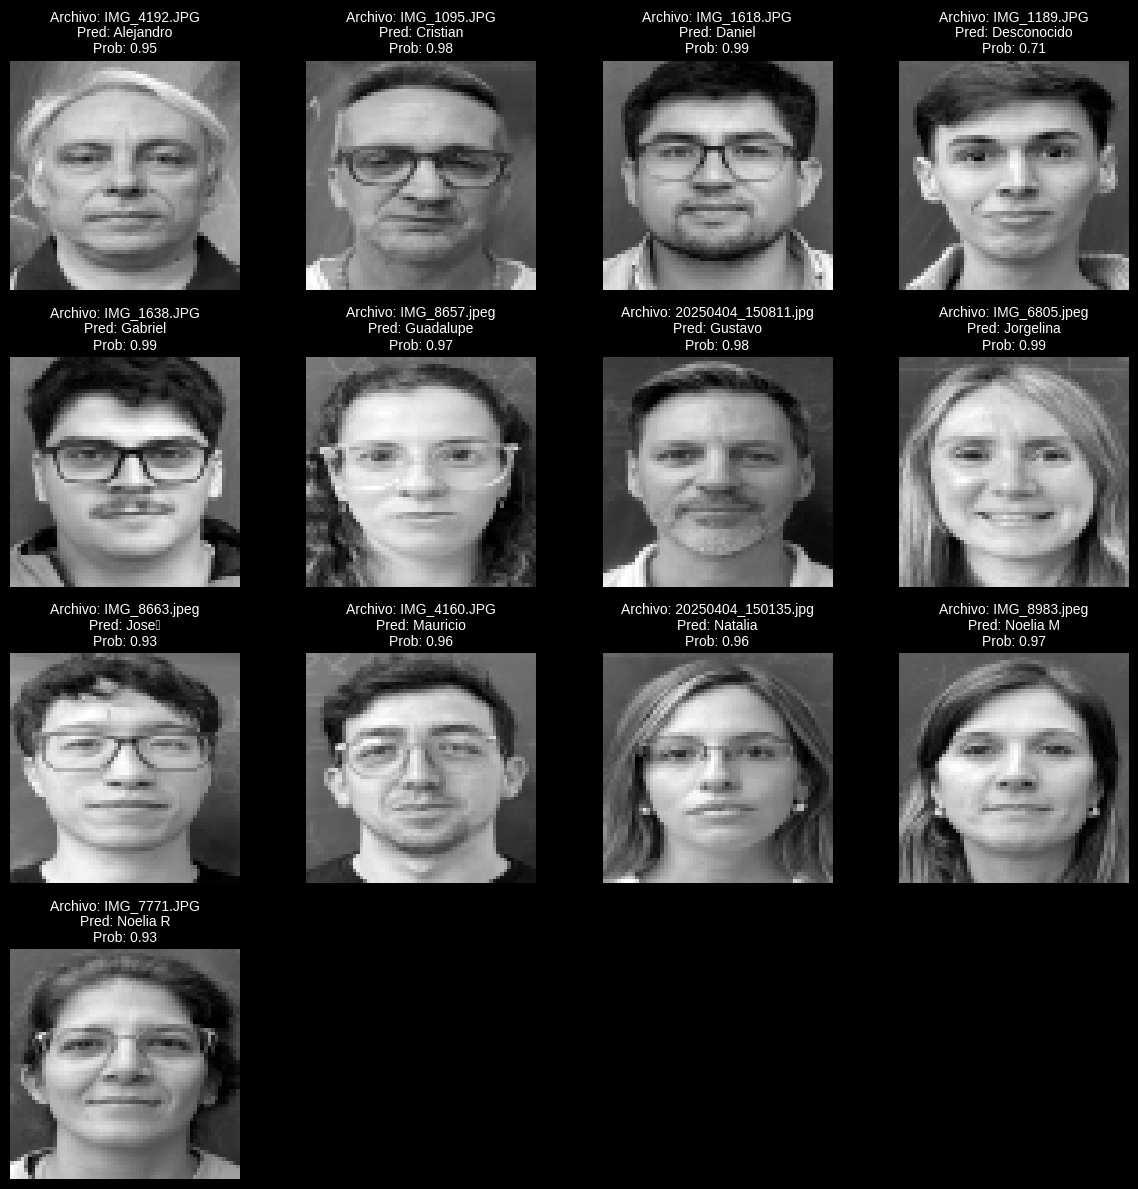

In [54]:
print("\nRealizando predicciones en las nuevas imágenes...")
if nuevas_imagenes_raw.shape[0] > 0:
    (predicciones_idx, probabilidades, _) = red_neuronal.predecir(
        df_new=df_nuevas_imagenes,
        campos=input_cols,
        clase=None
    )
    # Obtiene la lista de etiquetas de texto del modelo entrenado
    output_values = red_neuronal.red['arq']['output_values']

    # Convierte probabilidades a una lista para facilitar el mapeo
    probabilidades_list = probabilidades.tolist()
    predicciones = []

    for i, prob in enumerate(probabilidades_list):
        if prob >= UMBRAL_RECONOCIMENTO:
            # Si la probabilidad es mayor o igual al umbral, usa la predicción original
            predicciones.append(output_values[predicciones_idx[i]])
        else:
            # Si es menor, se considera "Desconocido"
            predicciones.append("Desconocido")

    print("\n--- Resultados de la predicción para las nuevas imágenes ---")
    print("Predicciones de clase:", predicciones)
    print("Probabilidades:", probabilidades_list)

    # Visualizar las imágenes con las predicciones
    visualize_faces(cropped_faces, filenames, predicciones, probabilidades_list)

else:
    print("No hay datos para predecir.")



## Visualiza resultados sobre las imágenes originales.
( Predicciones y Probabilidades ).

/tmp/ipython-input-3683970874.py:30: UserWarning: Glyph 769 (\N{COMBINING ACUTE ACCENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 769 (\N{COMBINING ACUTE ACCENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


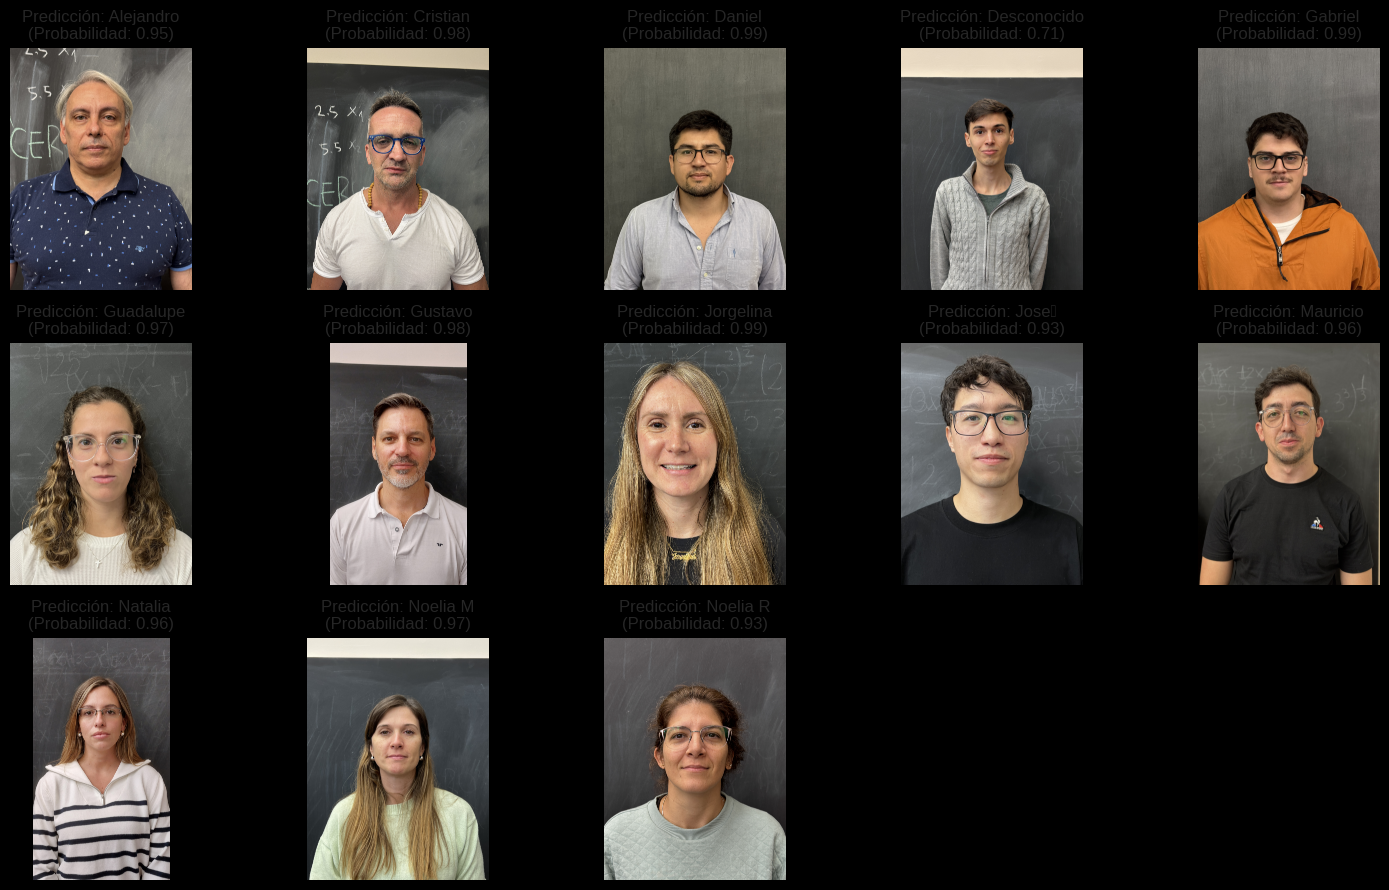

In [55]:
# Comprueba si se han realizado predicciones antes de intentar la visualizacion.
if 'predicciones' in locals() and 'probabilidades' in locals() and 'filenames' in locals() and len(filenames) > 0:
    num_images = len(filenames)
    cols = 5
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(15, 3 * rows))
    plt.style.use('seaborn-v0_8-whitegrid')

    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)

        # Carga la imagen original para mostrarla
        img_path = os.path.join(NUEVAS_IMAGENES_PATH, filenames[i])
        img_original = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img_original is not None:
            # Muestra la imagen
            img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.axis('off') # Oculta los ejes

            # Crea el título con la predicción y la probabilidad
            prediccion_texto = f'Predicción: {predicciones[i]}'
            probabilidad_texto = f'Probabilidad: {probabilidades[i]:.2f}'
            ax.set_title(f'{prediccion_texto}\n({probabilidad_texto})', fontsize=12)
        else:
            ax.set_title(f"No se pudo cargar\n{filenames[i]}", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones para mostrar. Asegúrese de que se cargaron imágenes y se realizaron predicciones correctamente.")